In [1]:
import pandas as pd
df = pd.read_csv("Economic_Indicators.csv", encoding='latin-1') #original path file wasnt working
pd.set_option('display.max_rows', None)
df

,Country Name,Country Code,Series Name,Series Code,2000 [YR2000],2001 [YR2001],2002 [YR2002],2003 [YR2003],2004 [YR2004],2005 [YR2005],...,2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020],2021 [YR2021],2022 [YR2022],2023 [YR2023]
0,Afghanistan,AFG,GDP (constant 2015 US$),NY.GDP.MKTP.KD,6206547590.07403,5621147630.73068,7228795918.92525,7867263256.28817,7978515641.58304,8874480195.58321,...,18860496494.0404,19134221644.7325,19566715174.1633,20084646751.4954,20323499020.3639,21118473702.3471,20621957125.2077,16345202562.5485,15325233810.1388,15740683549.2312
1,Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,..,..,..,..,..,12.6862687216715,...,4.67399603536305,-0.66170916471352,4.38389195513893,4.97595150553892,0.626149149168983,2.30237251516819,..,..,..,..
2,Afghanistan,AFG,Real interest rate (%),FR.INR.RINR,..,..,..,..,..,..,...,14.3516893380043,12.2525481629518,17.5839381624543,12.1411782956513,..,..,..,..,..,..
3,Afghanistan,AFG,"Official exchange rate (LCU per US$, period av...",PA.NUS.FCRF,47.3575747311828,47.500014516129,47.263,48.7627535833333,47.8453125,49.4945975,...,57.2475,61.1434615416667,67.8660857692308,68.0269040822312,72.083247177304,77.7379491783367,76.8135364354897,..,..,..
4,Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,..,..,..,..,..,..,...,7.915,..,..,11.184,..,..,11.71,5.679,..,..
5,Afghanistan,AFG,"Foreign direct investment, net (BoP, current US$)",BN.KLT.DINV.CD,..,..,..,..,..,..,...,-42994416.2107173,-166983554.911685,-79585268.7492387,-40273161.0002353,-80631404.0721353,2916492.92940283,24258330.1122418,..,..,..
6,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,..,..,..,..,..,..,...,..,..,..,..,..,..,46.7098945514103,51.4117163747271,72.8854696086536,67.2733432760503
7,Afghanistan,AFG,Gini index,SI.POV.GINI,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
8,Albania,ALB,GDP (constant 2015 US$),NY.GDP.MKTP.KD,6057218861.96683,6559562958.94637,6857139117.39279,7236245479.6585,7635300387.08491,8057259479.00459,...,11139693788.8124,11386853113.0189,11764325094.2129,12211675169.6845,12702504600.374,12964502337.0284,12534895529.6924,13659219676.8332,14318507636.8055,14882173624.9218
9,Albania,ALB,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,0.0500181363468309,3.10758827031434,7.77052583431552,0.48400261181847,2.28001916938101,2.36658195679796,...,1.6258650440261,1.89617402592365,1.2754316836741,1.98666133171199,2.02805963071136,1.41109078954246,1.62088661717011,2.04147163139549,6.72520271530048,4.75976421930107


In [2]:
# Rename main columns for clarity and to follow good coding practices.
df.rename(columns={
    'Country Name': 'Country',
    'Country Code': 'Country_Code',
    'Series Name': 'Indicator',
    'Series Code': 'Indicator_Code',
  }, inplace=True)

In [3]:
df.columns = [col.replace(" [YR", "").replace("]", "")
 if " [YR" in col
else col for col in df.columns]

df.columns = [col[:4]
  if col[:4].isdigit()
else col for col in df.columns]
#cleans column to remove the duplicate years in square brackets



In [4]:
rename_dict = {
    'GDP (constant 2015 US$)': 'GDP_per_Capita',
    'Inflation, consumer prices (annual %)': 'Inflation_Rate',
    'Real interest rate (%)': 'Interest_Rate',
    'Unemployment, total (% of total labor force) (national estimate)': 'Unemployment_Rate',
    'Foreign direct investment, net (BoP, current US$)': 'FDI_Net_Inflows',
    'Gini index': 'Gini_Coefficient',
    'Individuals using the Internet (% of population)': 'Internet_Usage',
    'Labor force participation rate for ages 15–24, total (%) (national estimate)': 'Youth_Labor_Participation',
    'Labor force participation rate, female (% of female population ages 15–64) (modeled ILO estimate)': 'Female_Labor_Participation',
    'Official exchange rate (LCU per US$, period average)': 'Exchange_Rate',
}

#renaming all the indicators to more appriate names


In [5]:
df['Indicator'] = df['Indicator'].replace(rename_dict)
#renames the values inside the 'Indicator' column.

In [6]:
print("\nRenamed Columns:\n", df.columns)
print("\nSample Unique Indicator Names:\n", df['Indicator'].unique())
#confirm that the renaming or cleaning worked



Renamed Columns:
 Index(['Country', 'Country_Code', 'Indicator', 'Indicator_Code', '2000',
       '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018',
       '2019', '2020', '2021', '2022', '2023'],
      dtype='object')

Sample Unique Indicator Names:
 ['GDP_per_Capita' 'Inflation_Rate' 'Interest_Rate' 'Exchange_Rate'
 'Unemployment_Rate' 'FDI_Net_Inflows' 'Trade (% of GDP)'
 'Gini_Coefficient' nan]


In [7]:
df.head(20)  # Preview the cleaned dataframe (first 20 rows)

,Country,Country_Code,Indicator,Indicator_Code,2000,2001,2002,2003,2004,2005,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,AFG,GDP_per_Capita,NY.GDP.MKTP.KD,6206547590.07403,5621147630.73068,7228795918.92525,7867263256.28817,7978515641.58304,8874480195.58321,...,18860496494.0404,19134221644.7325,19566715174.1633,20084646751.4954,20323499020.3639,21118473702.3471,20621957125.2077,16345202562.5485,15325233810.1388,15740683549.2312
1,Afghanistan,AFG,Inflation_Rate,FP.CPI.TOTL.ZG,..,..,..,..,..,12.6862687216715,...,4.67399603536305,-0.66170916471352,4.38389195513893,4.97595150553892,0.626149149168983,2.30237251516819,..,..,..,..
2,Afghanistan,AFG,Interest_Rate,FR.INR.RINR,..,..,..,..,..,..,...,14.3516893380043,12.2525481629518,17.5839381624543,12.1411782956513,..,..,..,..,..,..
3,Afghanistan,AFG,Exchange_Rate,PA.NUS.FCRF,47.3575747311828,47.500014516129,47.263,48.7627535833333,47.8453125,49.4945975,...,57.2475,61.1434615416667,67.8660857692308,68.0269040822312,72.083247177304,77.7379491783367,76.8135364354897,..,..,..
4,Afghanistan,AFG,Unemployment_Rate,SL.UEM.TOTL.NE.ZS,..,..,..,..,..,..,...,7.915,..,..,11.184,..,..,11.71,5.679,..,..
5,Afghanistan,AFG,FDI_Net_Inflows,BN.KLT.DINV.CD,..,..,..,..,..,..,...,-42994416.2107173,-166983554.911685,-79585268.7492387,-40273161.0002353,-80631404.0721353,2916492.92940283,24258330.1122418,..,..,..
6,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,..,..,..,..,..,..,...,..,..,..,..,..,..,46.7098945514103,51.4117163747271,72.8854696086536,67.2733432760503
7,Afghanistan,AFG,Gini_Coefficient,SI.POV.GINI,..,..,..,..,..,..,...,..,..,..,..,..,..,..,..,..,..
8,Albania,ALB,GDP_per_Capita,NY.GDP.MKTP.KD,6057218861.96683,6559562958.94637,6857139117.39279,7236245479.6585,7635300387.08491,8057259479.00459,...,11139693788.8124,11386853113.0189,11764325094.2129,12211675169.6845,12702504600.374,12964502337.0284,12534895529.6924,13659219676.8332,14318507636.8055,14882173624.9218
9,Albania,ALB,Inflation_Rate,FP.CPI.TOTL.ZG,0.0500181363468309,3.10758827031434,7.77052583431552,0.48400261181847,2.28001916938101,2.36658195679796,...,1.6258650440261,1.89617402592365,1.2754316836741,1.98666133171199,2.02805963071136,1.41109078954246,1.62088661717011,2.04147163139549,6.72520271530048,4.75976421930107


In [8]:
# Replace common placeholders with NaN
df = df.replace(["..", "", "N/A", "null", "NaN"], pd.NA)

# Convert all year columns to numeric (force non-numeric values to NaN)
for col in df.columns[4:]:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Check missing values again
missing_values_fixed = df.isnull().sum()

# Display missing values again
print("\n Updated Missing Values Count:\n")
print(missing_values_fixed)



 Updated Missing Values Count:

Country             3
Country_Code        5
Indicator           5
Indicator_Code      5
2000              589
2001              584
2002              551
2003              540
2004              520
2005              468
2006              466
2007              467
2008              456
2009              435
2010              422
2011              424
2012              414
2013              420
2014              400
2015              417
2016              425
2017              434
2018              447
2019              454
2020              496
2021              495
2022              558
2023              685
dtype: int64


In [9]:
# Identify all numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns

# fill remaining NaNs in numerical columns with 0
df[numerical_columns] = df[numerical_columns].fillna(0)

# Recheck for missing values
missing_counts = df.isnull().sum()
print(missing_counts)

Country           3
Country_Code      5
Indicator         5
Indicator_Code    5
2000              0
2001              0
2002              0
2003              0
2004              0
2005              0
2006              0
2007              0
2008              0
2009              0
2010              0
2011              0
2012              0
2013              0
2014              0
2015              0
2016              0
2017              0
2018              0
2019              0
2020              0
2021              0
2022              0
2023              0
dtype: int64


In [10]:
# Identify all numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns

# Fill missing values in each row with the median of that row
df[numerical_columns] = df[numerical_columns].T.fillna(df[numerical_columns].median(axis=1)).T

# Verify if all missing values are handled
missing_counts = df.isnull().sum()
print("\n Missing Values After Row-Wise Imputation:\n")
print(missing_counts)


 Missing Values After Row-Wise Imputation:

Country           3
Country_Code      5
Indicator         5
Indicator_Code    5
2000              0
2001              0
2002              0
2003              0
2004              0
2005              0
2006              0
2007              0
2008              0
2009              0
2010              0
2011              0
2012              0
2013              0
2014              0
2015              0
2016              0
2017              0
2018              0
2019              0
2020              0
2021              0
2022              0
2023              0
dtype: int64


In [11]:
df.head(20)  # Preview the cleaned dataframe (first 20 rows)

,Country,Country_Code,Indicator,Indicator_Code,2000,2001,2002,2003,2004,2005,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Afghanistan,AFG,GDP_per_Capita,NY.GDP.MKTP.KD,6.206548e+09,5.621148e+09,7.228796e+09,7.867263e+09,7.978516e+09,8.874480e+09,...,1.886050e+10,1.913422e+10,1.956672e+10,2.008465e+10,2.032350e+10,2.111847e+10,2.062196e+10,1.634520e+10,1.532523e+10,1.574068e+10
1,Afghanistan,AFG,Inflation_Rate,FP.CPI.TOTL.ZG,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.268627e+01,...,4.673996e+00,-6.617092e-01,4.383892e+00,4.975952e+00,6.261491e-01,2.302373e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,Afghanistan,AFG,Interest_Rate,FR.INR.RINR,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,1.435169e+01,1.225255e+01,1.758394e+01,1.214118e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
3,Afghanistan,AFG,Exchange_Rate,PA.NUS.FCRF,4.735757e+01,4.750001e+01,4.726300e+01,4.876275e+01,4.784531e+01,4.949460e+01,...,5.724750e+01,6.114346e+01,6.786609e+01,6.802690e+01,7.208325e+01,7.773795e+01,7.681354e+01,0.000000e+00,0.000000e+00,0.000000e+00
4,Afghanistan,AFG,Unemployment_Rate,SL.UEM.TOTL.NE.ZS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,7.915000e+00,0.000000e+00,0.000000e+00,1.118400e+01,0.000000e+00,0.000000e+00,1.171000e+01,5.679000e+00,0.000000e+00,0.000000e+00
5,Afghanistan,AFG,FDI_Net_Inflows,BN.KLT.DINV.CD,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,-4.299442e+07,-1.669836e+08,-7.958527e+07,-4.027316e+07,-8.063140e+07,2.916493e+06,2.425833e+07,0.000000e+00,0.000000e+00,0.000000e+00
6,Afghanistan,AFG,Trade (% of GDP),NE.TRD.GNFS.ZS,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.670989e+01,5.141172e+01,7.288547e+01,6.727334e+01
7,Afghanistan,AFG,Gini_Coefficient,SI.POV.GINI,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
8,Albania,ALB,GDP_per_Capita,NY.GDP.MKTP.KD,6.057219e+09,6.559563e+09,6.857139e+09,7.236245e+09,7.635300e+09,8.057259e+09,...,1.113969e+10,1.138685e+10,1.176433e+10,1.221168e+10,1.270250e+10,1.296450e+10,1.253490e+10,1.365922e+10,1.431851e+10,1.488217e+10
9,Albania,ALB,Inflation_Rate,FP.CPI.TOTL.ZG,5.001814e-02,3.107588e+00,7.770526e+00,4.840026e-01,2.280019e+00,2.366582e+00,...,1.625865e+00,1.896174e+00,1.275432e+00,1.986661e+00,2.028060e+00,1.411091e+00,1.620887e+00,2.041472e+00,6.725203e+00,4.759764e+00


In [12]:
# Melt the dataset: turn years into rows
df_melted = df.melt(
    id_vars=['Country', 'Country_Code', 'Indicator', 'Indicator_Code'],
    value_vars=[str(y) for y in range(2000, 2024)],
    var_name='Year',
    value_name='Value'
)

# Pivot so that each Indicator becomes its own column
df_pivot = df_melted.pivot_table(
    index=['Country', 'Year'],
    columns='Indicator',
    values='Value',
    aggfunc='first'  # Just in case there are duplicates
).reset_index()

# Clean up column names
df_pivot.columns.name = None

# View result
print("Pivoted DataFrame with Indicators as Columns:")

df_pivot.head(100)


Pivoted DataFrame with Indicators as Columns:


,Country,Year,Exchange_Rate,FDI_Net_Inflows,GDP_per_Capita,Gini_Coefficient,Inflation_Rate,Interest_Rate,Trade (% of GDP),Unemployment_Rate
0,Afghanistan,2000,47.357575,0.000000e+00,6.206548e+09,0.0,0.000000,0.000000,0.000000,0.000
1,Afghanistan,2001,47.500015,0.000000e+00,5.621148e+09,0.0,0.000000,0.000000,0.000000,0.000
2,Afghanistan,2002,47.263000,0.000000e+00,7.228796e+09,0.0,0.000000,0.000000,0.000000,0.000
3,Afghanistan,2003,48.762754,0.000000e+00,7.867263e+09,0.0,0.000000,0.000000,0.000000,0.000
4,Afghanistan,2004,47.845312,0.000000e+00,7.978516e+09,0.0,0.000000,0.000000,0.000000,0.000
5,Afghanistan,2005,49.494597,0.000000e+00,8.874480e+09,0.0,12.686269,0.000000,0.000000,0.000
6,Afghanistan,2006,49.925331,0.000000e+00,9.349922e+09,0.0,6.784597,10.046897,0.000000,0.000
7,Afghanistan,2007,49.962018,0.000000e+00,1.064267e+10,0.0,8.680571,-3.585111,0.000000,0.000
8,Afghanistan,2008,50.249615,-4.795178e+07,1.106040e+10,0.0,26.418664,12.557960,0.000000,2.495
9,Afghanistan,2009,50.325000,-5.586014e+07,1.342627e+10,0.0,-6.811161,17.542929,0.000000,0.000


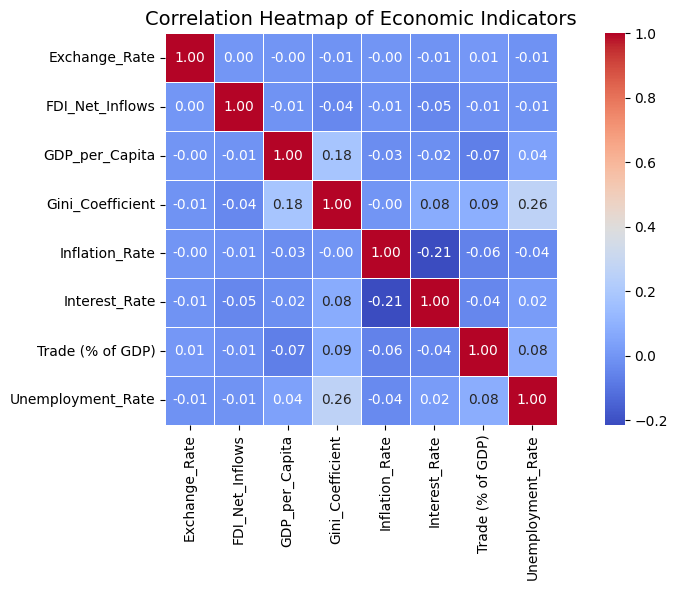

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_df = df_pivot.select_dtypes(include='number')

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5,
            square=True)

plt.title("Correlation Heatmap of Economic Indicators", fontsize=14)
plt.tight_layout()
plt.show()

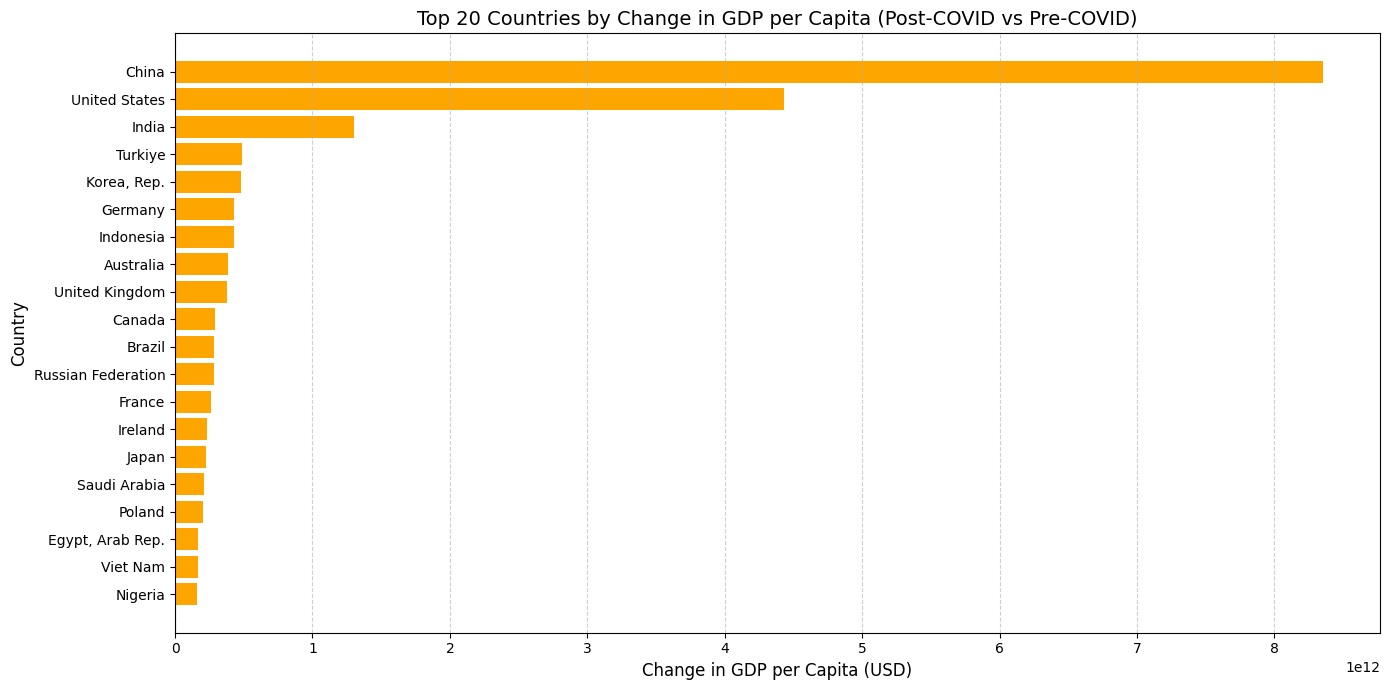

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure 'Year' is numeric
df_pivot['Year'] = pd.to_numeric(df_pivot['Year'])

# Calculate pre- and post-COVID GDP per Capita averages
pre_covid = df_pivot[df_pivot['Year'] < 2020].groupby('Country')['GDP_per_Capita'].mean()
post_covid = df_pivot[df_pivot['Year'] >= 2020].groupby('Country')['GDP_per_Capita'].mean()

# Merge and calculate the difference
gdp_change = pd.DataFrame({
    'Pre-COVID': pre_covid,
    'Post-COVID': post_covid
})
gdp_change['Change'] = gdp_change['Post-COVID'] - gdp_change['Pre-COVID']

# Sort by change
gdp_change_sorted = gdp_change.sort_values(by='Change', ascending=False).dropna().head(20)

plt.figure(figsize=(14, 7))
plt.barh(gdp_change_sorted.index, gdp_change_sorted['Change'], color='orange')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Top 20 Countries by Change in GDP per Capita (Post-COVID vs Pre-COVID)', fontsize=14)
plt.xlabel('Change in GDP per Capita (USD)', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [15]:
import plotly.graph_objects as go

selected_countries = ['United States', 'China']
latest_year = df_pivot['Year'].max()
indicators = ['GDP_per_Capita', 'Inflation_Rate', 'Unemployment_Rate', 'FDI_Net_Inflows']

#Filter and normalize indicator values for fair comparison
data = df_pivot[df_pivot['Year'] == latest_year][['Country'] + indicators]
data = data[data['Country'].isin(selected_countries)].dropna()

#normalises data using min max scaling
normalized_data = data.copy()
for col in indicators:
    col_min = df_pivot[df_pivot['Year'] == latest_year][col].min()
    col_max = df_pivot[df_pivot['Year'] == latest_year][col].max()
    normalized_data[col] = (normalized_data[col] - col_min) / (col_max - col_min)

fig = go.Figure()

for i, row in normalized_data.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=row[indicators].values,
        theta=indicators,
        fill='toself',
        name=row['Country']
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 1])
    ),
    title="Economic Profile Comparison (Radar Chart)",
    showlegend=True
)

fig.show()